In [ ]:
# Obtained with Roboflow
Road_points = {"points": [[[0, 273.125], [586.875, 48.125], [626.25, 53.75], [515.625, 359], [1.25, 359]]]}

In [2]:
from utlis.RoadEntity import AreaEntity

if len(Road_points["points"]) == 1:
    Road_area = AreaEntity(Road_points["points"])
    # pts = np.array(Road_points["points"], np.int32)
    # pts = pts.reshape((-1, 1, 2))

In [3]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO 

model = YOLO("yolov8n.pt")  # 使用 YOLOv8 最輕量版

video_path = 'Pedestrian_on_roads_1.mp4'
cap = cv2.VideoCapture(video_path)
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))


In [4]:
ret, frame = cap.read()
#cv2.imwrite(video_path[:video_path.index(".mp4")]+"_screenshot.jpg", frame)

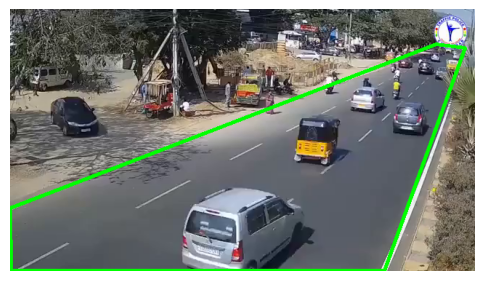

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# 定義多邊形的頂點
# pts = np.array([[100, 100], [200, 50], [300, 100], [250, 200], [150, 200]], np.int32)
# pts = pts.reshape((-1, 1, 2))


# 繪製多邊形
cv2.polylines(frame, [Road_area.contour], isClosed=True, color=(0, 255, 0), thickness=3)

# 轉換 BGR 到 RGB (因為 matplotlib 使用 RGB)
img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 用 Matplotlib 顯示影像
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")  # 隱藏座標軸
plt.show()


In [6]:
# --------------- 透過滑鼠點擊已知物體來回推比例換算 --------------- #
# import cv2
# import numpy as np

# # **1. 設定已知物體的尺寸**
# REAL_WORLD_LENGTH_M = 4  # 例如：白虛線的長度 (公尺)
# KNOWN_PIXEL_LENGTH = 80  # 在圖片或影片中測得的像素長度

# # **2. 計算 1 像素代表多少公尺**
# meters_per_pixel = REAL_WORLD_LENGTH_M / KNOWN_PIXEL_LENGTH
# print(f"每 1 像素 ≈ {meters_per_pixel:.4f} 公尺")

# # **3. 載入圖片並手動選擇兩點來測量距離**
# image_path = video_path[:video_path.index(".mp4")]+"_screenshot.jpg"  # 輸入影像
# image = cv2.imread(image_path)

# # **4. 讓使用者在影像中選擇兩點**
# points = []

# def click_event(event, x, y, flags, param):
#     """ 滑鼠點擊事件：選取兩個點來計算距離 """
#     global points
#     if event == cv2.EVENT_LBUTTONDOWN:
#         points.append((x, y))
#         cv2.circle(image, (x, y), 5, (0, 0, 255), -1)
#         if len(points) == 2:
#             cv2.line(image, points[0], points[1], (255, 0, 0), 2)
#             cv2.imshow("Image", image)
#             calculate_distance(points)

# def calculate_distance(points):
#     """ 計算兩點之間的實際距離 """
#     px_distance = np.linalg.norm(np.array(points[0]) - np.array(points[1]))  # 計算像素距離
#     real_distance = px_distance * meters_per_pixel  # 轉換為公尺
#     print(f"兩點的像素距離: {px_distance:.2f} px")
#     print(f"實際距離: {real_distance:.2f} m")

# cv2.imshow("Image", image)
# cv2.setMouseCallback("Image", click_event)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# # 每 1 像素 ≈ 0.0500 公尺
# # 兩點的像素距離: 80.53 px
# # 實際距離: 4.03 m

In [6]:
# **需偵測的類別**
detect_classes = {0:"Person", 1:"Bicycle", 2: "Car", 3: "Motorcycle", 5: "Bus", 7: "Truck"}


In [7]:
out = cv2.VideoWriter("Pedestrian_on_roads_1_detect_area.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))


# **軌跡**
vehicle_tracks = {}  # 存放車輛的歷史座標 {ID: [(x, y, frame_number)]}
frame_count = 0  # 記錄當前幀數

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    cv2.polylines(frame, [Road_area.contour], isClosed=True, color=(255, 255, 255), thickness=3)


    results = model(frame)
    
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0].item())
            conf = box.conf[0].item()
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cx, cy = (x1+x2)//2, (y1+y2)//2

            result = cv2.pointPolygonTest(Road_area.contour, (x2, y1), measureDist=False)

            if class_id in detect_classes and conf>0.5:
                label_color = (0, 255, 0)
                if result > 0:
                    if class_id == 0:
                        label_color = (0, 0, 255)
                    else:
                        label_color = (255, 0, 0)
                
                label = f"{detect_classes[class_id]} {conf:.2f}"
                cv2.rectangle(frame, (x1, y1), (x2, y2), label_color, 2)
                cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, label_color, 2)

    cv2.imshow("Vehicle Detection", frame)
    out.write(frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):  # 按 Q 退出
        break

# **釋放資源**
cap.release()
out.release()
cv2.destroyAllWindows()



0: 384x640 1 person, 8 cars, 3 trucks, 157.9ms
Speed: 3.0ms preprocess, 157.9ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 8 cars, 4 trucks, 162.8ms
Speed: 9.3ms preprocess, 162.8ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 7 cars, 1 bus, 3 trucks, 134.1ms
Speed: 2.9ms preprocess, 134.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 6 cars, 1 bus, 3 trucks, 143.0ms
Speed: 2.0ms preprocess, 143.0ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 6 cars, 1 bus, 3 trucks, 137.7ms
Speed: 3.0ms preprocess, 137.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 7 cars, 1 bus, 3 trucks, 146.8ms
Speed: 2.0ms preprocess, 146.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 6 cars, 3 trucks, 140.2ms
Speed: 4.4ms preprocess, 140.2ms inference,

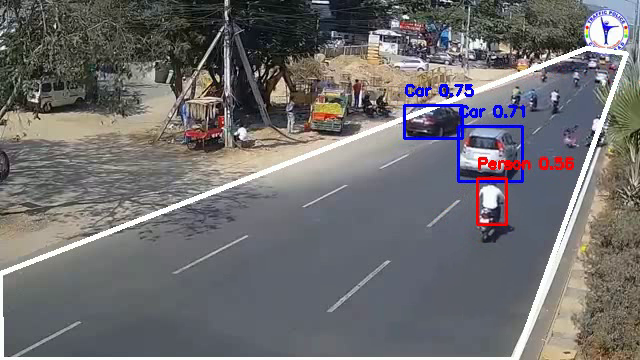

In [10]:
import cv2
import IPython.display as display
from PIL import Image

cap = cv2.VideoCapture("Pedestrian_on_roads_1_detect_area.mp4")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # OpenCV 預設是 BGR，轉換為 RGB
    img = Image.fromarray(frame)
    
    display.clear_output(wait=True)
    display.display(img)  # 顯示當前幀
    
cap.release()
